In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow import keras
from skimage.metrics import structural_similarity as ssim
import os
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense, Dropout
import cv2
from tqdm import tqdm
import tqdm as notebook_tqdm
import imutils
import pywt

2026-03-05 11:10:16.264528: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-05 11:10:16.828078: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-05 11:10:19.061818: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Discreet Wavelet Transform version of the vortex function
def wavelet_distillation(distilled_image):
    # Perform a 2D Discrete Wavelet Transform
    # 'haar' is great for detecting intensity jumps (tumor boundaries)
    coeffs2 = pywt.dwt2(distilled_image, 'haar')
    LL, (LH, HL, HH) = coeffs2
    
    # LL is the 'Approximation' (the general shape)
    # LH, HL, HH are 'Details' (the edges/texture)
    
    # We can stack these to create a multi-resolution feature map
    # This gives the model 4x the 'logic' to work with
    wavelet_stack = np.block([
        [LL, LH],
        [HL, HH]
    ])
    
    return wavelet_stack



# Fast Fourier Transform version of the vortex function
def myfft2(A): 
    return np.fft.fftshift(np.fft.fft2(np.fft.fftshift(A)))

In [3]:
def generate_vortex_map(f, A, m, dim=64, xmax=10, flambda=80):
    """
    Applies a vortex phase of charge 'm' to a batch of images 'A'.
    
    Parameters:
    A (ndarray): Input image batch of shape [num_images, dim, dim]
    m (int): Topological charge (1, 2, 3, etc.)
    dim (int): Pixel resolution of the grid
    xmax (float): Physical limit of the f-plane
    flambda (float): Lens parameter
    
    Returns:
    ndarray: Processed and normalized images of shape [num_images, dim, dim]
    """
    # 1. Setup Coordinates
    dx = 2 * xmax / dim
    x = np.linspace(-xmax, xmax - dx, dim)
    X, Y = np.meshgrid(x, x)
    R2 = (X**2 + Y**2)
    T = np.arctan2(Y, X)

    # 2. Create the LG Mask (Lens + Vortex Phase)
    Lens = np.exp(-1j * R2 / (flambda / 10))
    Vortex = np.exp(1j * m * T)
    LG_mask = Lens * Vortex

    # 3. Process the Batch
    num_images = A.shape[0]
    out = np.zeros_like(A, dtype=np.float64)
    
    for i in range(num_images):
        # Apply phase modulation and distillation 
        # (Assumes wavelet_distillation is defined globally)
        phase_mod = np.exp(1j * A[i] * np.pi * 2)
        distilled = f(phase_mod * LG_mask)
        
        # Calculate Magnitude
        A_mag = np.abs(distilled)
        
        # Normalize to [-1, 1] for NN compatibility
        a_min = np.amin(A_mag)
        a_diff = np.amax(A_mag) - a_min
        
        if a_diff != 0:
            out[i] = (A_mag - a_min) / a_diff * 2 - 1
        else:
            out[i] = A_mag - a_min

    return out

In [4]:
from tensorflow.keras.utils import to_categorical

DIM = 256           # Image dimension 
NUM_CLASSES = 4     # Number of tumor categories


def load_and_preprocess_data(data_dir):
    """Loads images as a dataset, converts to NumPy, and gets integer labels."""
    print(f"Loading data from: {data_dir}")

    ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        labels='inferred',
        label_mode='int', # Load as integers
        image_size=(DIM, DIM),
        batch_size=None, # Load all data into one tensor
        shuffle=False
    )
    # Convert to NumPy array
    # x shape will be (N, DIM, DIM, 3)
    x = np.array([item[0].numpy() for item in ds])
    y = np.array([item[1].numpy() for item in ds])
    
    return x, y


# Load preprocessed training and testing data
x_train, y_train = load_and_preprocess_data('/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Brain Tumor Dataset/Training/')
x_test, y_test = load_and_preprocess_data('/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Brain Tumor Dataset/Testing/')

# Number of training and testing samples
n_train, n_test = x_train.shape[0], x_test.shape[0]

print(f"\nTraining Samples: {n_train}, Testing Samples: {n_test}")


def convert_to_grayscale_batch(images_rgb_batch, N_samples):
    """Converts a batch of (N, H, W, 3) images to (N, H, W, 1) grayscale using cv2."""
    # Initialize an empty array for the final grayscale data
    images_gray_batch = np.empty((N_samples, DIM, DIM, 1), dtype=np.float32)

    # Loop through the batch and apply the conversion image-by-image
    for i in tqdm(range(N_samples), desc="Converting to Grayscale"):
        # OpenCV needs uint8 format (0-255)
        image_uint8 = images_rgb_batch[i].astype(np.uint8)
        
        # Perform the conversion (Output is 2D: H x W)
        gray_2d = cv2.cvtColor(image_uint8, cv2.COLOR_RGB2GRAY)
        
        # Add the channel dimension back and store (Shape: H x W x 1)
        images_gray_batch[i] = gray_2d[..., np.newaxis]
        
    return images_gray_batch

# Normalize to [0, 1] range
x_train = convert_to_grayscale_batch(x_train, n_train) / 255.0
x_test = convert_to_grayscale_batch(x_test, n_test) / 255.0


def downsample_batch(images_batch, target_dim):
    """Resizes a batch of images from (N, 256, 256) to (N, target_dim, target_dim)."""
    print(f"Downsampling images from {images_batch.shape[1]}x{images_batch.shape[2]} to {target_dim}x{target_dim}...")
    
    downsampled_images = np.empty((images_batch.shape[0], target_dim, target_dim), dtype=np.float32)
    
    # Loop and resize each image
    for i in tqdm(range(images_batch.shape[0]), desc="Resizing Images"):
        # The INTER_AREA interpolation is best for shrinking images
        downsampled_images[i] = cv2.resize(images_batch[i], 
                                           (target_dim, target_dim), 
                                           interpolation=cv2.INTER_AREA)
    return downsampled_images


DIM = 64  # New dimension after downsampling-

# X_train_vort_input is now (N, 32, 32)
x_train = downsample_batch(x_train, DIM)
x_test = downsample_batch(x_test, DIM)


# Lablels
y_train = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test = to_categorical(y_test, num_classes=NUM_CLASSES)

# Remove the single channel dimension (axis=-1) for the 'vort_THIS' function.
print(x_train.shape, x_test.shape)
#x_train = np.squeeze(x_train, axis=-1)
#x_test = np.squeeze(x_test, axis=-1)

Loading data from: /mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Brain Tumor Dataset/Training/
Found 5712 files belonging to 4 classes.


2026-03-05 11:10:30.786373: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Loading data from: /mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Brain Tumor Dataset/Testing/
Found 1311 files belonging to 4 classes.


2026-03-05 11:10:37.399961: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-05 11:10:42.020474: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Training Samples: 5712, Testing Samples: 1311


...

Downsampling images from 256x256 to 64x64...


Resizing Images: 100%|██████████| 5712/5712 [00:00<00:00, 19995.75it/s]


Downsampling images from 256x256 to 64x64...


Resizing Images: 100%|██████████| 1311/1311 [00:00<00:00, 21276.80it/s]

(5712, 64, 64) (1311, 64, 64)


In [11]:
CUSTOM_OBJECTS = {
            # 1. Metrics (Likely Source of Error)
            'keras.metrics.MSE': tf.keras.metrics.MeanSquaredError(),
            'MSE': tf.keras.metrics.MeanSquaredError(),
            'mse': tf.keras.metrics.MeanSquaredError(),
            
            # 2. Loss Functions (Possible Source of Error)
            'mean_squared_error': tf.keras.losses.MeanSquaredError(),
            
            # 3. Optimizers (Needed if you want to resume training, though not needed for prediction)
            'rmsprop': tf.keras.optimizers.RMSprop() 
        }


model_path = f'/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Reconstruction Models/Wavelet/2pi/wavelet_distillation_m_1.keras'
reconstruction_model = load_model(model_path, custom_objects=CUSTOM_OBJECTS)

X_DWT = generate_vortex_map(wavelet_distillation, x_train, m=1)
recon_tumor_DWT = reconstruction_model.predict(X_DWT.reshape(len(X), 64**2))

X_FFT = generate_vortex_map(myfft2, x_train, m=1)
recon_tumor_FFT = reconstruction_model.predict(X_FFT.reshape(len(X), 64**2))

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [12]:
y_integers = np.argmax(y_train, axis=1)
epsilon = 1e-4

class_means = {}
class_map = {0: 'Glioma', 1: 'Meningioma', 2: 'No_Tumor', 3: 'Pituitary'}

for c in class_map.keys():
    mask = (y_integers == c)
    if np.any(mask):
        mean_data = np.mean(recon_tumor_DWT[mask], axis=0)
        # Ensure 64x64 shape
        class_means[c] = mean_data.reshape(64, 64) if mean_data.size == 4096 else mean_data
    else:
        class_means[c] = np.zeros((64, 64))


pairs = [(2, 0), (2, 1), (2, 3), (0, 1), (1, 3)]
results = {}

for start, end in pairs:
    m0, m1 = class_means[start], class_means[end]
        
    # Haar DWT
    coeffs0 = pywt.dwt2(m0, 'haar')
    coeffs1 = pywt.dwt2(m1, 'haar')
    
    LL0, (LH0, HL0, HH0) = coeffs0
    LL1, (LH1, HL1, HH1) = coeffs1
    
    bands = {'LL': (LL0, LL1), 'LH': (LH0, LH1), 'HL': (HL0, HL1), 'HH': (HH0, HH1)}
    pair_name = f"{class_map[start]}_vs_{class_map[end]}"
    results[pair_name] = {}

    for name, (b0, b1) in bands.items():
        grad = b1 - b0
        # FI calculation: (Difference^2) / (Intensity + eps)
        fi_val = np.sum((grad**2) / (np.abs(b1) + epsilon))
        results[pair_name][name] = fi_val



print(results)

{'No_Tumor_vs_Glioma': {'LL': np.float32(39.36236), 'LH': np.float32(27.438145), 'HL': np.float32(31.632309), 'HH': np.float32(23.23168)}, 'No_Tumor_vs_Meningioma': {'LL': np.float32(23.962341), 'LH': np.float32(27.138191), 'HL': np.float32(47.587395), 'HH': np.float32(17.502048)}, 'No_Tumor_vs_Pituitary': {'LL': np.float32(25.968952), 'LH': np.float32(28.418383), 'HL': np.float32(36.001095), 'HH': np.float32(18.392725)}, 'Glioma_vs_Meningioma': {'LL': np.float32(12.005642), 'LH': np.float32(7.7579403), 'HL': np.float32(12.369248), 'HH': np.float32(4.1728454)}, 'Meningioma_vs_Pituitary': {'LL': np.float32(10.37034), 'LH': np.float32(8.996414), 'HL': np.float32(14.091479), 'HH': np.float32(6.2453437)}}


In [18]:
import numpy as np
import pywt

def calculate_full_dataset_dwt_fi(X_train, y_train, epsilon=1e-4):
    y_ints = np.argmax(y_train, axis=1)
    
    # 1. Get the "Anchor": The Average Healthy Brain (Class 2)
    healthy_images = X_train[y_ints == 2]
    healthy_mean = np.mean(healthy_images, axis=0).reshape(64, 64)
    coeffs_healthy = pywt.dwt2(healthy_mean, 'haar')
    LL_h, (LH_h, HL_h, HH_h) = coeffs_healthy

    # 2. Storage for FI results
    # We want an FI value for every image in the dataset
    fi_scores = {c: [] for c in range(4)}

    for i in range(len(X_train)):
        img = X_train[i].reshape(64, 64)
        label = y_ints[i]
        
        # Perform DWT on the individual image
        coeffs_img = pywt.dwt2(img, 'haar')
        LL_i, (LH_i, HL_i, HH_i) = coeffs_img
        
        # We focus on the Detail Bands (LH, HL, HH) as they hold the 15% signal
        # FI = sum( (Detail_Img - Detail_Healthy_Mean)^2 / (Abs(Detail_Img) + epsilon) )
        total_fi = 0
        for band_img, band_h in [(LH_i, LH_h), (HL_i, HL_h), (HH_i, HH_h)]:
            numerator = (band_img - band_h)**2
            denominator = np.abs(band_img) + epsilon
            total_fi += np.sum(numerator / denominator)
        
        fi_scores[label].append(total_fi)

    # 3. Calculate Stats for your Results Table
    stats = {}
    class_names = {0: 'Glioma', 1: 'Meningioma', 2: 'No_Tumor', 3: 'Pituitary'}
    for c, scores in fi_scores.items():
        stats[class_names[c]] = {
            'Mean_FI': np.mean(scores),
            'Std_FI': np.std(scores)
        }
    
    return stats

FI_DWT = calculate_full_dataset_dwt_fi(recon_tumor_DWT, y_train)

print(FI_DWT)

{'Glioma': {'Mean_FI': np.float32(295.05017), 'Std_FI': np.float32(58.48875)}, 'Meningioma': {'Mean_FI': np.float32(330.94006), 'Std_FI': np.float32(67.011406)}, 'No_Tumor': {'Mean_FI': np.float32(408.55905), 'Std_FI': np.float32(132.51694)}, 'Pituitary': {'Mean_FI': np.float32(328.3874), 'Std_FI': np.float32(57.250576)}}


In [15]:
def calculate_full_dataset_fft_fi(X_train, y_train, epsilon=1e-4):
    y_ints = np.argmax(y_train, axis=1)
    
    # 1. Get the "Anchor": The Average Healthy Brain (Class 2)
    healthy_images = X_train[y_ints == 2]
    # Ensure 64x64 and take the Magnitude of the 2D FFT
    healthy_mean = np.mean(healthy_images, axis=0).reshape(64, 64)
    fft_healthy = np.abs(np.fft.fft2(healthy_mean))

    # 2. Storage for FFT FI scores
    fft_fi_scores = {c: [] for c in range(4)}

    for i in range(len(X_train)):
        img = X_train[i].reshape(64, 64)
        label = y_ints[i]
        
        # 2D FFT Magnitude of the individual image
        fft_img = np.abs(np.fft.fft2(img))
        
        # FI = sum( (FFT_Img - FFT_Healthy_Mean)^2 / (FFT_Img + epsilon) )
        # Summed over all N=4096 frequency bins
        numerator = (fft_img - fft_healthy)**2
        denominator = fft_img + epsilon
        total_fi = np.sum(numerator / denominator)
        
        fft_fi_scores[label].append(total_fi)

    # 3. Calculate Stats
    stats = {}
    class_names = {0: 'Glioma', 1: 'Meningioma', 2: 'No_Tumor', 3: 'Pituitary'}
    for c, scores in fft_fi_scores.items():
        stats[class_names[c]] = {
            'Mean_FFT_FI': np.mean(scores),
            'Std_FFT_FI': np.std(scores)
        }
    
    return stats

FI_FFT = calculate_full_dataset_fft_fi(recon_tumor_FFT, y_train)
print(FI_FFT)

{'Glioma': {'Mean_FFT_FI': np.float32(1233.3586), 'Std_FFT_FI': np.float32(260.80862)}, 'Meningioma': {'Mean_FFT_FI': np.float32(1332.0466), 'Std_FFT_FI': np.float32(272.39685)}, 'No_Tumor': {'Mean_FFT_FI': np.float32(1729.442), 'Std_FFT_FI': np.float32(869.1159)}, 'Pituitary': {'Mean_FFT_FI': np.float32(1251.6471), 'Std_FFT_FI': np.float32(331.3768)}}


In [19]:
# Augment the training dataset to add 3x more data

def augment_image(x_train, y_train):
    augmented_x = []
    augmented_y = []

    for i in range(len(x_train)):
        img = x_train[i]
        label = y_train[i]

        # --- 1. Generate 4 Versions of the Image ---
        # Version A: Original
        # Version B: Horizontal Flip
        # Version C: 90-degree Rotation (Standard for NIH Axial views)
        # Version D: 180-degree Rotation

        versions = [img, np.fliplr(img), np.rot90(img, 1), np.rot90(img, 2)]

        # Now add them all into the augmented dataset
        for v in versions:
            augmented_x.append(v)
            augmented_y.append(label)

    return np.array(augmented_x), np.array(augmented_y)


# Augment the training data
x_train_aug, y_train_aug = augment_image(x_train, y_train)

X_DWT_aug = generate_vortex_map(wavelet_distillation, x_train_aug, m=1)
recon_tumor_DWT_aug = reconstruction_model.predict(X_DWT_aug.reshape(len(X_DWT_aug), 64**2))


FI_DWT_aug = calculate_full_dataset_dwt_fi(recon_tumor_DWT_aug, y_train_aug)
#FI_DWT = calculate_full_dataset_dwt_fi(recon_tumor_DWT, y_train)
print(FI_DWT_aug)

714/714 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
{'Glioma': {'Mean_FI': np.float32(286.87827), 'Std_FI': np.float32(56.871796)}, 'Meningioma': {'Mean_FI': np.float32(323.53595), 'Std_FI': np.float32(64.846725)}, 'No_Tumor': {'Mean_FI': np.float32(409.67038), 'Std_FI': np.float32(130.12698)}, 'Pituitary': {'Mean_FI': np.float32(319.44904), 'Std_FI': np.float32(57.61143)}}


In [41]:
class_dist = 1.0 # Classes are labeled 0, 1, 2, 3
CRLB = (1/3 * class_dist)**2 # CRLB is sigma^2

min_FI = 1/CRLB

print(f'The minimum Fisher Information (FI) required for unbiased estimation is: {min_FI:.4f}')
print('Beyond this minimum FI, you get diminishing returns.\n Since the FI are all in the 10e2 to 10e3 range, we are well above the minimum and both transforms provide enough data sensitivity to parameter changes.')

The minimum Fisher Information (FI) required for unbiased estimation is: 9.0000
Beyond this minimum FI, you get diminishing returns.
 Since the FI are all in the 10e2 to 10e3 range, we are well above the minimum and both transforms provide enough data sensitivity to parameter changes.


In [42]:
# Calculate the Coefficient of Variation (CV) for each class in the DWT and FFT FI results

CV_DWT_0 = FI_DWT['Glioma']['Std_FI'] / FI_DWT['Glioma']['Mean_FI']
CV_DWT_1 = FI_DWT['Meningioma']['Std_FI'] / FI_DWT['Meningioma']['Mean_FI']
CV_DWT_2 = FI_DWT['No_Tumor']['Std_FI'] / FI_DWT['No_Tumor']['Mean_FI']
CV_DWT_3 = FI_DWT['Pituitary']['Std_FI'] / FI_DWT['Pituitary']['Mean_FI']

CV_FFT_0 = FI_FFT['Glioma']['Std_FFT_FI'] / FI_FFT['Glioma']['Mean_FFT_FI']
CV_FFT_1 = FI_FFT['Meningioma']['Std_FFT_FI'] / FI_FFT['Meningioma']['Mean_FFT_FI']
CV_FFT_2 = FI_FFT['No_Tumor']['Std_FFT_FI'] / FI_FFT['No_Tumor']['Mean_FFT_FI']
CV_FFT_3 = FI_FFT['Pituitary']['Std_FFT_FI'] / FI_FFT['Pituitary']['Mean_FFT_FI']

print(f"Coefficient of Variation (CV) for DWT FI:")
print(f"  Class 0: {CV_DWT_0:.4f}")
print(f"  Class 1: {CV_DWT_1:.4f}")
print(f"  Class 2: {CV_DWT_2:.4f}")
print(f"  Class 3: {CV_DWT_3:.4f}")

print(f"\nCoefficient of Variation (CV) for FFT FI:")
print(f"  Class 0: {CV_FFT_0:.4f}")
print(f"  Class 1: {CV_FFT_1:.4f}")
print(f"  Class 2: {CV_FFT_2:.4f}")
print(f"  Class 3: {CV_FFT_3:.4f}")

Coefficient of Variation (CV) for DWT FI:
  Class 0: 0.1982
  Class 1: 0.2025
  Class 2: 0.3244
  Class 3: 0.1743

Coefficient of Variation (CV) for FFT FI:
  Class 0: 0.2115
  Class 1: 0.2045
  Class 2: 0.5025
  Class 3: 0.2648


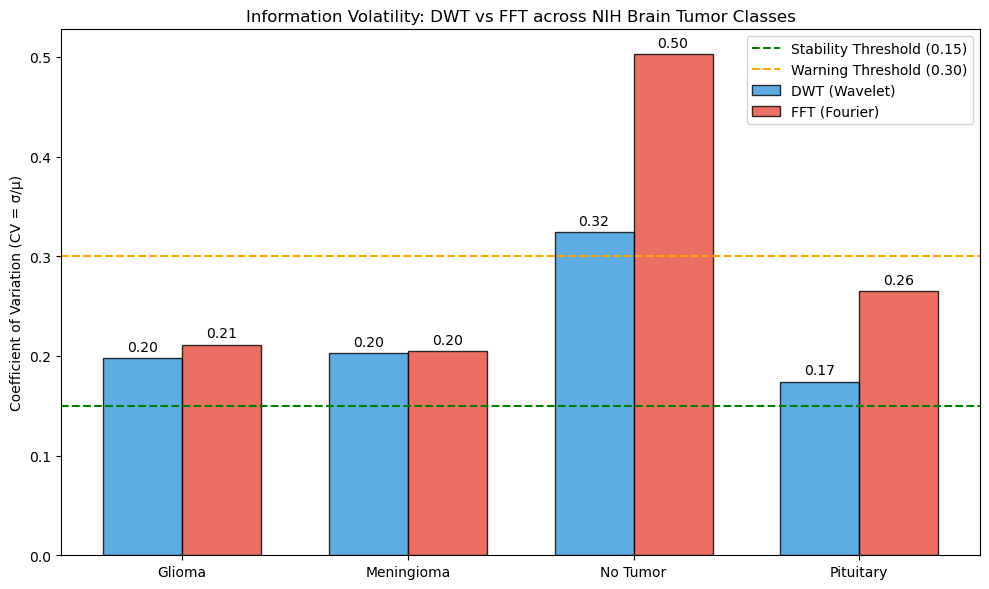

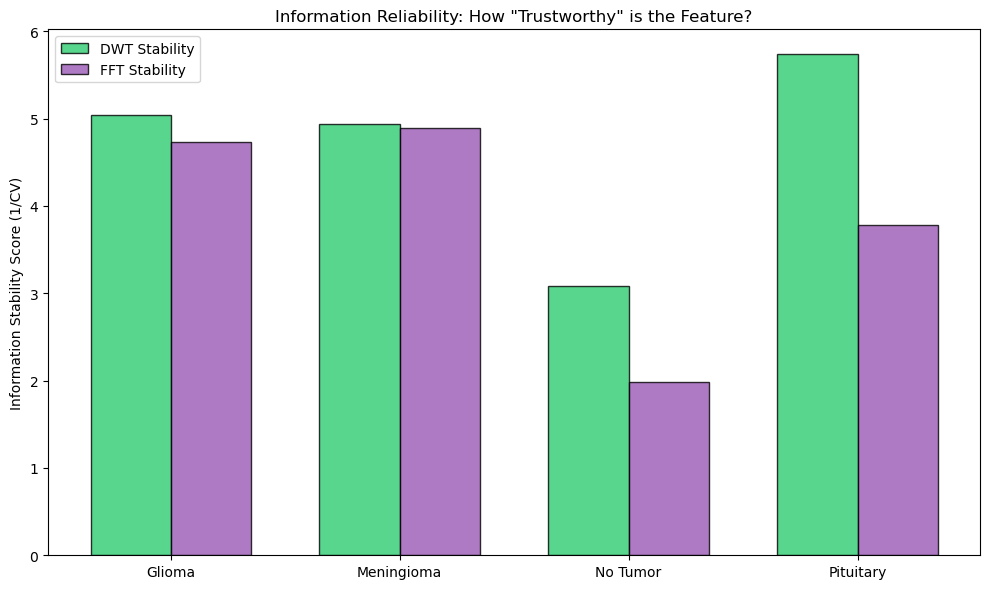

In [43]:
# Data provided by the user
classes = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
dwt_cv = [CV_DWT_0, CV_DWT_1, CV_DWT_2, CV_DWT_3]
fft_cv = [CV_FFT_0, CV_FFT_1, CV_FFT_2, CV_FFT_3]

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, dwt_cv, width, label='DWT (Wavelet)', color='#3498db', edgecolor='black', alpha=0.8)
rects2 = ax.bar(x + width/2, fft_cv, width, label='FFT (Fourier)', color='#e74c3c', edgecolor='black', alpha=0.8)

# Add a horizontal line for the "Stability Threshold" discussed (15% or 0.15)
ax.axhline(y=0.15, color='green', linestyle='--', label='Stability Threshold (0.15)')

# Add a line for the "Warning Zone" (30% or 0.30)
ax.axhline(y=0.30, color='orange', linestyle='--', label='Warning Threshold (0.30)')

ax.set_ylabel('Coefficient of Variation (CV = σ/μ)')
ax.set_title('Information Volatility: DWT vs FFT across NIH Brain Tumor Classes')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

# Label the values on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig('cv_comparison_plot.png')

# Now let's calculate the "Stability Score" logic mentioned
# Score = 1/CV (Higher is better/more stable)
dwt_stability = [1/v for v in dwt_cv]
fft_stability = [1/v for v in fft_cv]

fig2, ax2 = plt.subplots(figsize=(10, 6))
rects3 = ax2.bar(x - width/2, dwt_stability, width, label='DWT Stability', color='#2ecc71', edgecolor='black', alpha=0.8)
rects4 = ax2.bar(x + width/2, fft_stability, width, label='FFT Stability', color='#9b59b6', edgecolor='black', alpha=0.8)

ax2.set_ylabel('Information Stability Score (1/CV)')
ax2.set_title('Information Reliability: How "Trustworthy" is the Feature?')
ax2.set_xticks(x)
ax2.set_xticklabels(classes)
ax2.legend()

autolabel(rects3)
autolabel(rects4)

plt.tight_layout()
plt.savefig('stability_score_plot.png')